# The bootstrap

*Question, Intuition, Math, Code, Assumptions, How it breaks*

## 1. Question

The ranking says one player scored 2.94 and another 2.81. Is that a difference,
or is it noise?

Every number in that table is computed from a finite career, five seasons or
nineteen seasons, and a different set of seasons would have produced a slightly
different number. My question is how much slightly.

## 2. Intuition

If I could re-run a career a thousand times I would see how much the average
bounces around. I cannot. I have the seasons that actually happened.

The bootstrap's trick is to treat the seasons I do have **as if they were the
population**, and draw new careers out of them. Same length, sampling with
replacement, so some seasons show up twice and others not at all. Each fake
career gives me a mean. The spread of those means estimates the spread of the
real one.

It sounds like cheating. It works because the sample is my best available
picture of the population, and resampling from it mimics the sampling that
produced it in the first place.

## 3. Math

Given observations $x_1 \dots x_n$, for $b = 1 \dots B$:

1. Draw $n$ values from $\{x_i\}$ **with replacement**, giving $x^*_{1} \dots x^*_{n}$
2. Record $\bar{x}^*_b$, the mean of that draw

The 95% percentile interval is the 2.5th and 97.5th percentiles of
$\{\bar{x}^*_1 \dots \bar{x}^*_B\}$.

**With replacement is the whole method.** Sampling without replacement from $n$
observations hands you back the same $n$ observations every single time, and the
interval would come out zero-width.

I use $B = 10{,}000$. The percentile interval is the simplest of several
variants. BCa corrects for skew and bias, and it would be the upgrade if I were
using these intervals for formal inference rather than for saying "these two
players are not separable".

In [1]:
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.figsize"] = (10, 5.5)

SAMPLE = "../data/sample"
ranking = pd.read_parquet(f"{SAMPLE}/ranking.parquet")
seasons = pd.read_parquet(f"{SAMPLE}/player_season_scored.parquet")
offsets = pd.read_parquet(f"{SAMPLE}/league_offsets.parquet")

In [2]:
from gambeta import doubt

career = seasons[seasons["player"] == "Thierry Henry"]["season_score"].to_numpy()
print(f"{len(career)} seasons: {np.round(career, 2)}")

est, lo, hi = doubt.bootstrap(career, n=10_000)
print(f"\nmean {est:.3f}, 95% interval [{lo:.3f}, {hi:.3f}], width {hi - lo:.3f}")

10 seasons: [1.89 1.89 2.47 2.43 2.56 2.49 1.62 1.2  1.61 0.02]

mean 1.819, 95% interval [1.305, 2.227], width 0.922


Here is the machinery running, so that it is not a black box.

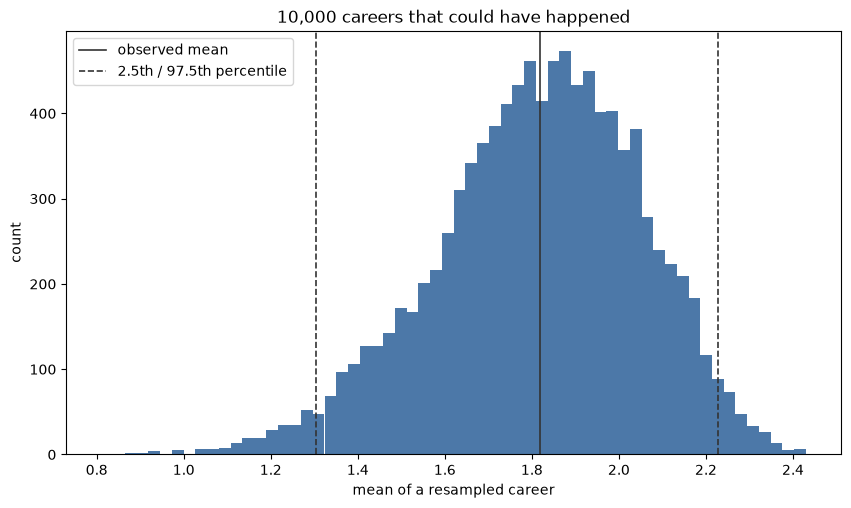

In [3]:
rng = np.random.default_rng(20260810)
draws = rng.choice(career, size=(10_000, len(career)), replace=True).mean(axis=1)

fig, ax = plt.subplots()
ax.hist(draws, bins=60, color="#4C78A8", edgecolor="none")
for value, style, label in [
    (career.mean(), "-", "observed mean"),
    (np.percentile(draws, 2.5), "--", "2.5th / 97.5th percentile"),
    (np.percentile(draws, 97.5), "--", None),
]:
    ax.axvline(value, color="#333", linestyle=style, linewidth=1.2, label=label)
ax.set_xlabel("mean of a resampled career")
ax.set_ylabel("count")
ax.set_title("10,000 careers that could have happened")
ax.legend()
plt.show()

## The interval narrows with evidence, not with effort

More seasons, more confidence. This is the one property worth checking by hand
before you trust any interval anybody hands you.

In [4]:
lengths = []
for n in (3, 5, 8, 12, 18):
    pool = seasons.groupby("player")["season_score"].agg(["count", "mean"])
    who = pool[pool["count"] == n]
    if not len(who):
        continue
    name = who["mean"].idxmax()
    values = seasons[seasons["player"] == name]["season_score"].to_numpy()
    mid, low, high = doubt.bootstrap(values, n=10_000)
    lengths.append(
        {"seasons": n, "player": name, "est": mid, "lo": low, "hi": high, "width": high - low}
    )

pd.DataFrame(lengths).round(3)

,seasons,player,est,lo,hi,width
0,3,Roberto Baggio,1.437,1.280,1.538,0.258
1,5,Ronaldo,1.460,0.904,1.848,0.944
2,8,Pauleta,1.484,1.104,1.826,0.723
3,12,Wissam Ben Yedder,1.166,1.015,1.316,0.302
4,18,Lionel Messi,2.285,1.924,2.624,0.699


## What the intervals do and do not license

Intervals invite a shortcut: *"their bands overlap, so we cannot tell them
apart."* **That shortcut is wrong**, and it gets a paragraph because it is
everywhere, including in this project's own Phase 1 write-up, which I wrote.

Non-overlap does imply a significant difference. The converse does not follow.
Two 95% intervals can overlap while the difference between the estimates is
comfortably significant, because the interval for a *difference* is narrower
than the two individual intervals make it look. Standard errors combine in
quadrature, not by addition.

So the count below describes the picture. It is not a test. The permutation chapter runs the
actual test, and on this data the two disagree on four pairs.

In [5]:
top = ranking[ranking["qualified"]].head(10)["player"].tolist()
bands = {}
for name in top:
    values = seasons[seasons["player"] == name]["season_score"].to_numpy()
    bands[name] = doubt.bootstrap(values, n=10_000)


def overlaps(x: str, y: str) -> bool:
    return bands[x][1] <= bands[y][2] and bands[y][1] <= bands[x][2]


pairs = [(a, b) for i, a in enumerate(top) for b in top[i + 1 :]]
print(f"{sum(overlaps(a, b) for a, b in pairs)} of {len(pairs)} pairs overlap\n")

# Where the heuristic and the actual test part company.
disagree = []
for a, b in pairs:
    if not overlaps(a, b):
        continue
    values_a = seasons[seasons["player"] == a]["season_score"].to_numpy()
    values_b = seasons[seasons["player"] == b]["season_score"].to_numpy()
    _, p = doubt.permutation_test(values_a, values_b, n=10_000, two_sided=True)
    if p < 0.05:
        disagree.append((a, b, p))

print(f"of those, {len(disagree)} are separable by a two-sided permutation test:")
for a, b, p in disagree:
    print(f"  {a} vs {b}: p = {p:.4f}")
print("\nThe overlap heuristic called every one of these 'inseparable'.")

40 of 45 pairs overlap



of those, 5 are separable by a two-sided permutation test:
  Lionel Messi vs Mohamed Salah: p = 0.0363
  Cristiano Ronaldo vs Luis Suárez: p = 0.0472
  Harry Kane vs Luis Suárez: p = 0.0487
  Erling Haaland vs Karim Benzema: p = 0.0449
  Kylian Mbappé vs Karim Benzema: p = 0.0263

The overlap heuristic called every one of these 'inseparable'.


## 5. Assumptions

1. **The observations are independent.** Resampling seasons assumes one season
   tells you nothing about the next. For a career that is questionable, because
   form, age and club quality all persist, and dependence makes the true
   interval *wider* than the bootstrap reports.
2. **The sample represents the population.** With five seasons it represents it
   badly, which the interval width reflects honestly enough.
3. **The statistic is smooth.** The bootstrap works well for means and poorly
   for maxima and anything else dominated by a single extreme observation.

## 6. How it breaks

**One observation gives perfect confidence.** This is not hypothetical. It
shipped, and it is recorded in `DEVIATIONS.md` #5.

In [6]:
print("a one-season 'career':", doubt.bootstrap(np.array([3.4]), n=10_000))
print("\nEvery resample of one number is that number, so the interval has zero")
print("width -- and renders as perfect certainty about the least certain")
print("estimate on the page. gambeta's answer is a minimum-seasons floor, not a")
print("cleverer interval: the problem is the question, not the arithmetic.")

a one-season 'career': (3.4, 3.4, 3.4)

Every resample of one number is that number, so the interval has zero
width -- and renders as perfect certainty about the least certain
estimate on the page. gambeta's answer is a minimum-seasons floor, not a
cleverer interval: the problem is the question, not the arithmetic.


**And a 95% interval from three seasons is not a 95% interval.** My floor is
`min_seasons = 3`, so the ranking does contain three-season careers with bands
printed next to them. I can measure what those bands are actually worth by
drawing from a distribution whose true mean I know, and counting how often the
interval contains it.

In [7]:
rng = np.random.default_rng(0)
rows = []
for n_obs in (3, 5, 10, 20):
    covered = 0
    trials = 400
    for _ in range(trials):
        sample = rng.normal(0, 1, n_obs)
        _, low, high = doubt.bootstrap(sample, n=800, seed=int(rng.integers(1e6)))
        covered += low <= 0 <= high
    rows.append(
        {"seasons": n_obs, "nominal": "95%", "actual coverage": f"{100 * covered / trials:.0f}%"}
    )

print(pd.DataFrame(rows).to_string(index=False))
print("\nAt three seasons a '95%' interval contains the truth about three times")
print("in four. The percentile bootstrap is known to under-cover in small")
print("samples; BCa would help, more seasons would help more. Until then the")
print("bands on the shortest careers are optimistic and should be read as such.")

 seasons nominal actual coverage
       3     95%             74%
       5     95%             85%
      10     95%             88%
      20     95%             92%

At three seasons a '95%' interval contains the truth about three times
in four. The percentile bootstrap is known to under-cover in small
samples; BCa would help, more seasons would help more. Until then the
bands on the shortest careers are optimistic and should be read as such.


**And here is the subtler failure: a narrow interval is not a correct one.** The
bootstrap quantifies sampling variability and nothing else. If the metric is
biased, if it systematically undervalues defenders say, then every single
resample carries that same bias and the interval sits confidently around the
wrong number.

An interval says *"if the world worked the way this model assumes, this is how
much the answer would wobble."* It never says the model was right.